# What does SPI–SPI add beyond simple summaries?

A focused exploratory comparison: an exactly specified intuition example, the proof-of-concept inter-class and CML embeddings, and headline results for all six system families in the lean order-parameter notebook. All p90 MPIs are reused from existing runs. Only the small, two-statistic VAR illustration is newly simulated. Original reference notebooks and frozen SPI–SPI coordinates are preserved.

**Question:** do relationships among dependence measures add useful structure beyond the average level or distribution of each measure? This is an empirical question. A more elaborate representation need not win.

The new comparisons reuse previously inspected data. They are retrospective, even when a system's original SPI–SPI result was independently confirmed. The separate [Zenodo appendix](spi_baseline_zenodo_260921.ipynb) explores the heterogeneous corpus without assigning a superiority score to its appearance.

In [1]:
from pathlib import Path
import sys, json
ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scripts.spi_baseline_exploration import OUT, DATA
from scripts import plot_spi_baseline_exploration as plots
plots.style()
pd.set_option("display.max_colwidth", 60)


## The abstraction and the baselines

An ordinary interaction network has measurement channels as its nodes. SPI–SPI can instead be viewed as a network whose nodes are **fixed scientific measures of dependence**. Its links describe their relationships within one recording. This changes the objects being compared: recordings need not share channel identities or channel counts, because the measures provide common reference points. A possible scientific interpretation is a *system-specific geometry of dependence measures*. This is a framing hypothesis, not evidence of a unique mechanism or a claim about the supervisor's exact intention.

This has a conceptual parallel with [representational similarity analysis](https://www.frontiersin.org/journals/systems-neuroscience/articles/10.3389/neuro.06.004.2008/full), which relates systems through relational structure without matching their measurement channels. The mathematical objects differ: our anchors are SPI definitions, and each recording determines relationships among those definitions. [Cliff et al.](https://arxiv.org/abs/2201.11941) already established the diverse SPI library and its empirical relationships across a large corpus; the library/corpus themselves are not new here.

For an off-diagonal edge vector $a_k$ from SPI $k$, define $m_k=\mathrm{mean}(a_k)$ and $z_{k\ell}=\mathrm{corr}(a_k,a_\ell)$. The baseline $m=(m_1,\dots,m_K)$ has **289 entries**, not one. It already supplies a common space. Thus common dimensionality alone cannot justify using the 41,616-entry $z$.

| Representation | What it tests | What it omits |
|:--|:--|:--|
| Mean Pearson $r$ and mean $\lvert r\rvert$ | Is elementary average linear dependence sufficient? | Most temporal and nonlinear structure |
| One mean per SPI | Is the catalogue's average response sufficient? | Within-SPI distributions and cross-SPI correspondence |
| Seven summaries per SPI: mean, SD, 10/25/50/75/90th percentiles | Does a gain survive retaining distribution shape? | Which values from different SPIs belong to the same pair |
| SPI–SPI | Does the relationship between different dependence profiles help? | Per-SPI means, positive scales and edge incidence |
| Means + SPI–SPI; distributions + SPI–SPI | Does combining complementary descriptions help? | Still a compressed representation; fusion is not guaranteed to help |

Signed means can cancel. Absolute values are therefore included for Pearson, but are not applied indiscriminately to every SPI: SPIs include signed statistics, distances and other quantities with different meanings. A finite constant MPI has a meaningful mean but undefined Pearson SPI–SPI correlations; missing values are not interpreted as zero dependence.

Feature length is independent of $M,T$; statistical values and estimator error need not be. Means also retain potentially useful information deliberately removed by Pearson SPI–SPI. Neither representation is universally richer. A statistic's output need not equal a physical coupling parameter. Catalogue-matched mean/distribution baselines still require the same p90 extraction; their simpler aggregation does not remove that cost. Raw Pearson is a genuinely cheaper route.

## 1. An intuition case whose population answer is known

Use a six-channel stationary Gaussian VAR(1): $x_t=A x_{t-1}+\epsilon_t$. Prescribe $C=\mathrm{Cov}(x_t)$ with unit diagonal and $L=\mathrm{Cov}(x_t,x_{t-1})$, then set

$$A=LC^{-1},\qquad \mathrm{Cov}(\epsilon_t)=C-LC^{-1}L^\top.$$

We check positive innovation covariance, stationarity and spectral radius below one. For the 15 unordered pairs, take evenly spaced $v_{ij}\in[-1,1]$ and set $C_{ij}=s+0.035v_{ij}$, $L_{ij}=0.01+0.03hv_{ij}$, with $s\in\{0.02,0.10\}$ and $h\in\{-1,+1\}$. Diagonals are $C_{ii}=1,L_{ii}=0.2$. Here $s$ controls average contemporaneous correlation, not physical coupling strength.

Changing $s$ changes the mean of C while leaving population $z(C,L)=h$ unchanged. Changing $h$ swaps aligned and opposed contemporaneous/lagged dependence profiles while preserving **the entire marginal distribution of each of these two MPIs**. Therefore their means, SDs and quantiles match across $h$. Both processes remain Gaussian and linear; a difference in z does not diagnose nonlinearity.

Each cell has 24 paired realizations, $T=6000$. Within each seed a common random dyad permutation is used for C and L; simulations start from the exact stationary distribution. The two probes are ordinary zero-lag and lag-one Pearson correlation, not the full p90 library. This is an information example, not evidence that SPI–SPI is the best estimator or predictor.

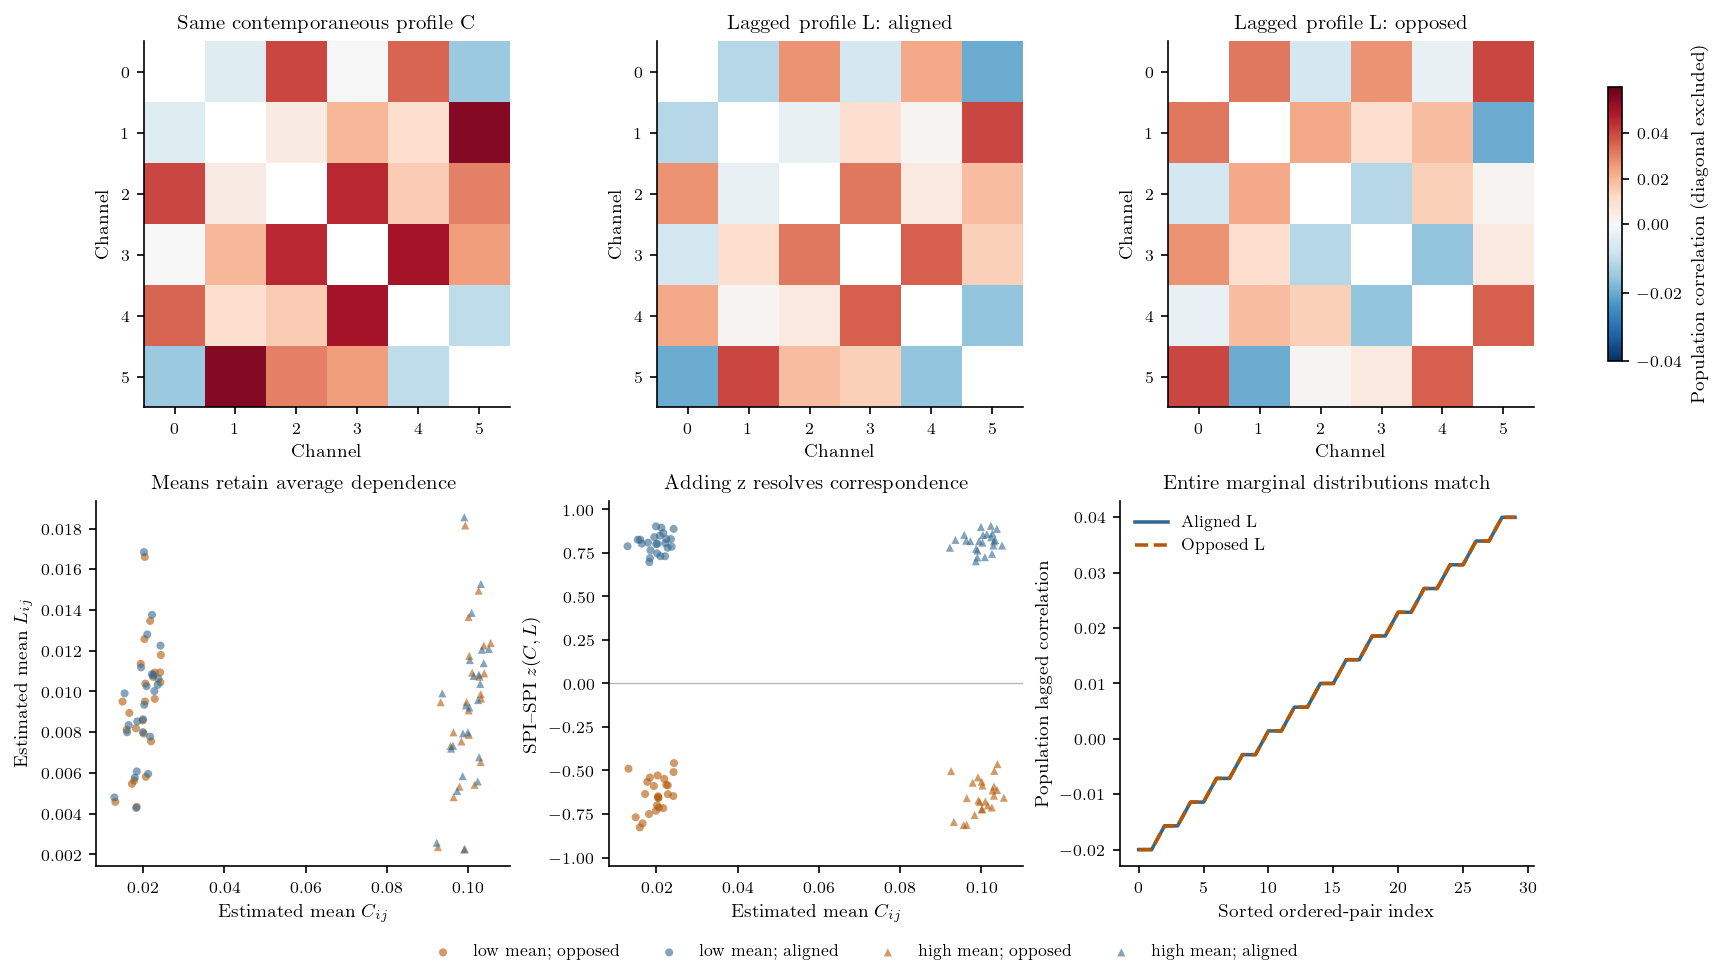

In [2]:
fig = plots.intuition()
plt.show()

In [3]:
display(pd.read_csv(OUT / 'intuition-population.csv')[['strength','orientation','mean_C','mean_L','z']].rename(columns={'strength':'s','orientation':'h'}).round(3))

,s,h,mean_C,mean_L,z
0,0.02,-1,0.02,0.01,-1.0
1,0.02,1,0.02,0.01,1.0
2,0.10,-1,0.10,0.01,-1.0
3,0.10,1,0.10,0.01,1.0


The exact table separates two roles: means describe average dependence; z describes how the chosen notions of dependence relate. Their combination distinguishes the four population cases. Finite-recording estimates scatter around that distinction. No mean-preserving manipulation of an arbitrary MPI is assumed realizable: these are actual stationary stochastic processes. Direct estimation of C and L also contains this information, so the illustration establishes a difference between compressions, not a unique SPI–SPI advantage. It does not establish that the full 289-SPI mean baseline fails on these processes: other SPIs may distinguish them.

## 2. Headline proof embeddings: inter-class and within CML

Use the original 1,260 development recordings (instances 0–9) and 2,520 evaluation recordings (10–29), spanning 14 classes and nine $M,T$ cells. The displayed maps retain the original exclusion of `brownian-defect`: 13 inter-class groups and five CML regimes. All 14 classes remain in the quantitative inter-class comparison and in the inherited SPI–SPI PCA basis.

This historical proof symmetrizes each MPI before taking its upper triangle. The new distribution baseline uses the same edges. Ordered-edge means would be identical when finite, but their distributions need not be. The original pyspi inputs were not channel-z-scored.

Each new baseline uses development-only 95% feature validity, median imputation, SD scaling and clipping at ±5 development SD, followed by PCA50 (or all available dimensions if fewer). Scaling is necessary because different SPIs have different units. The original frozen centre-only SPI–SPI PCA50 is reused exactly. Each feature block is normalized to unit total development variance; combinations concatenate the two PCA blocks and apply PCA50 again. This is one explicit fusion rule, not an optimal combination search.

For each representation, global UMAP is fitted on the 13 displayed development classes; a separate UMAP uses only the five development CML classes. Evaluation points are transformed into those maps. The PCA panels similarly fit a two-dimensional rotation on the relevant development subset. UMAP settings are fixed across representations: 30 neighbours, min_dist=.1, seed260824. Map shape, axis scale and inter-cluster gaps are not direct performance measures.

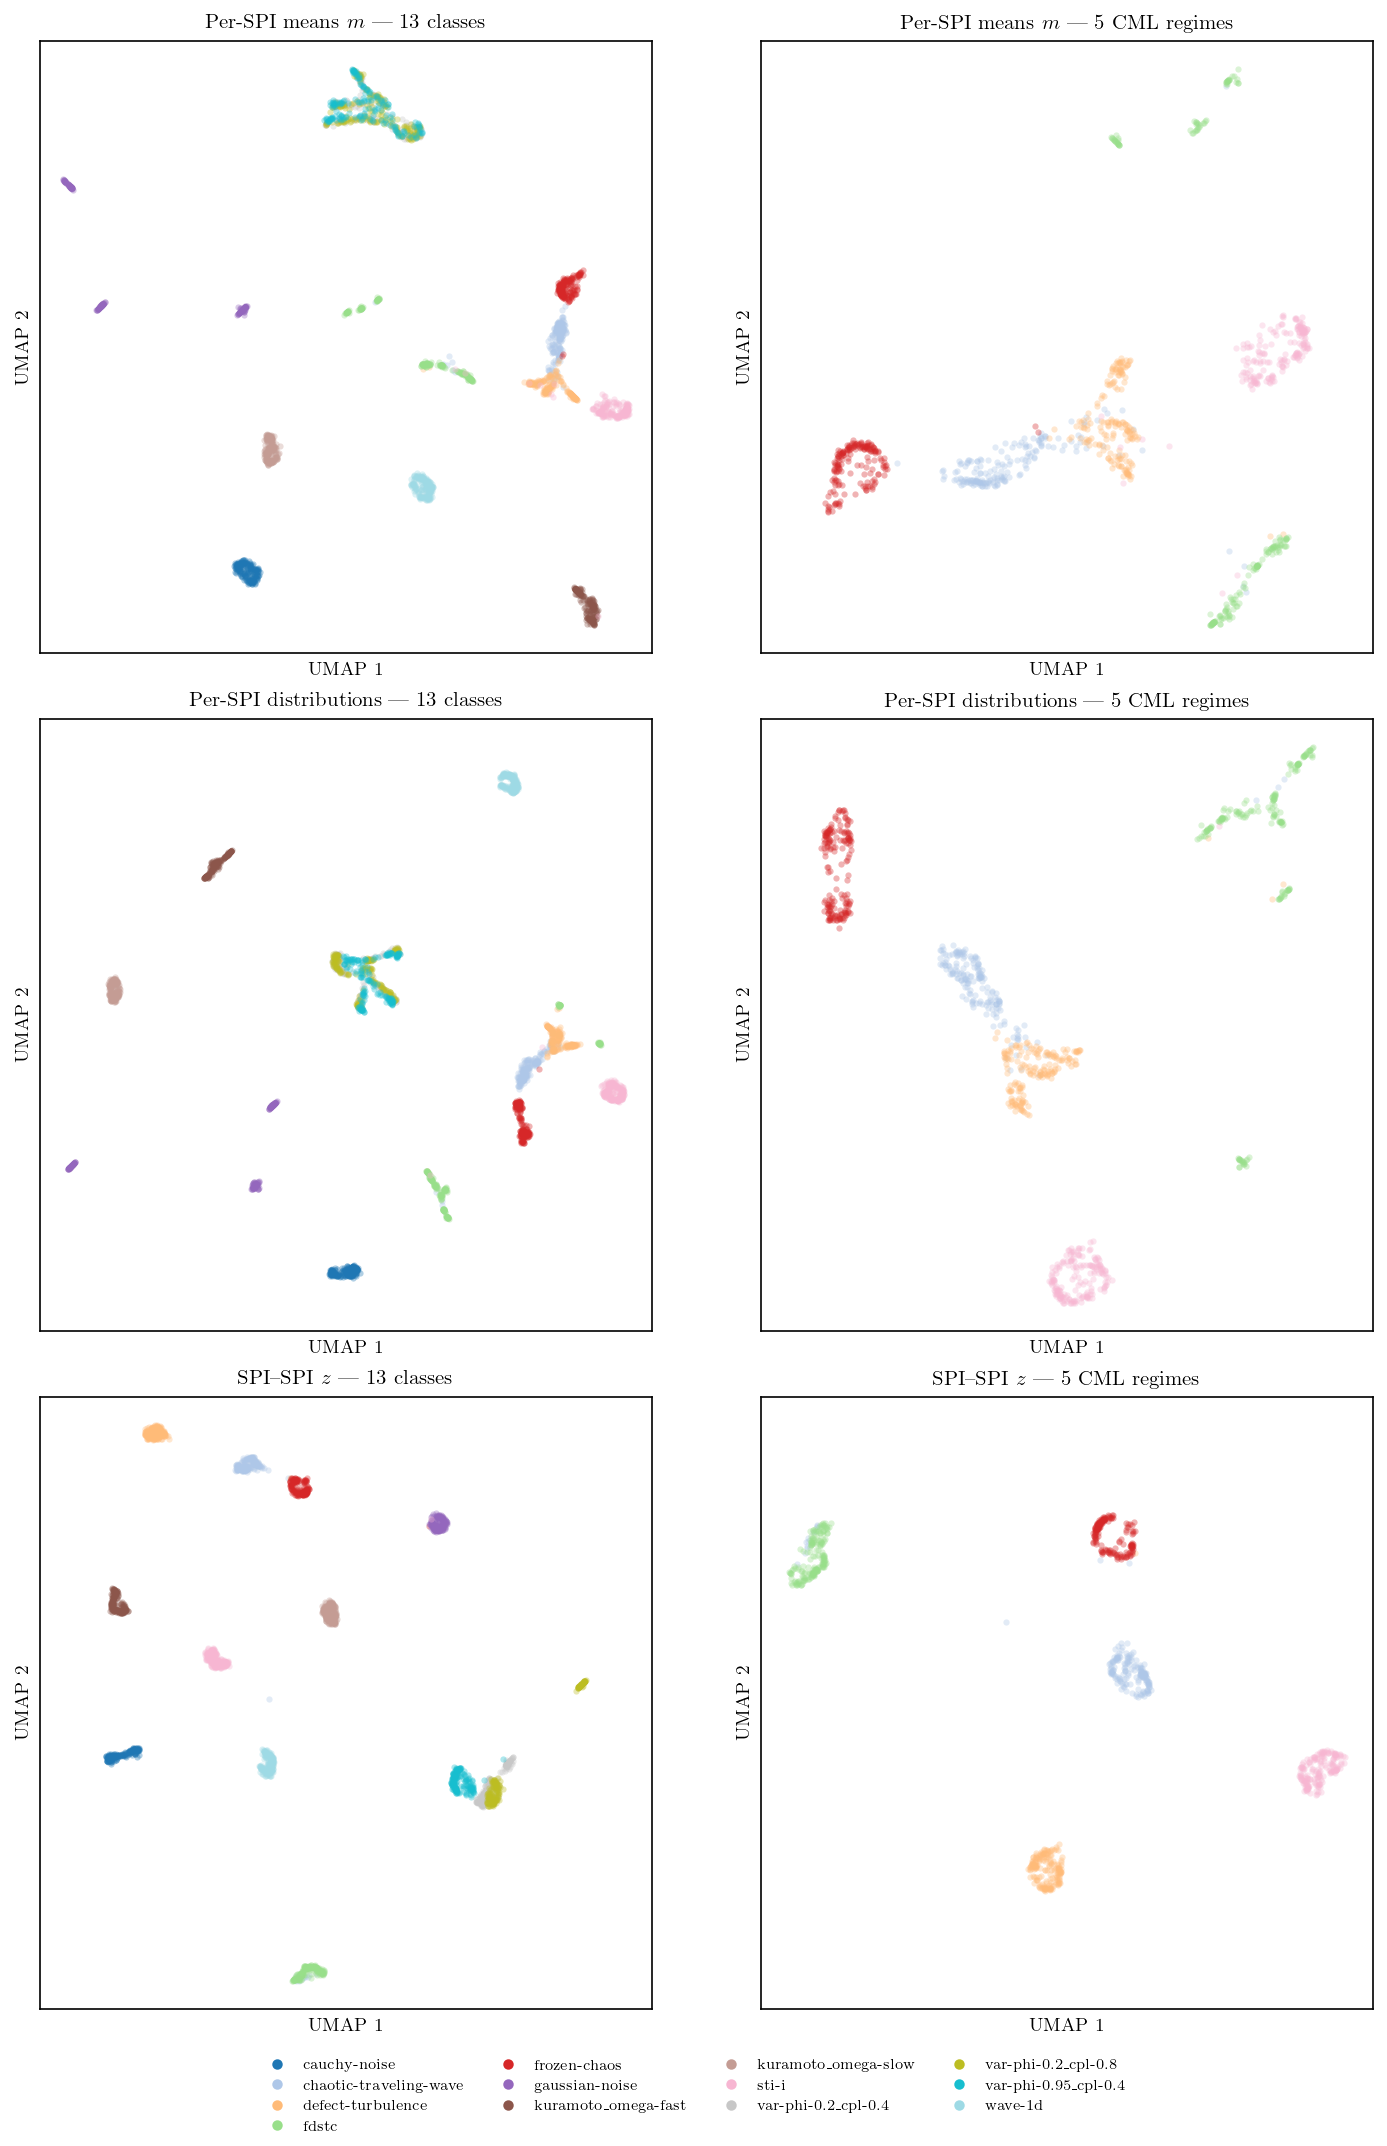

In [4]:
fig = plots.proof('umap')
plt.show()

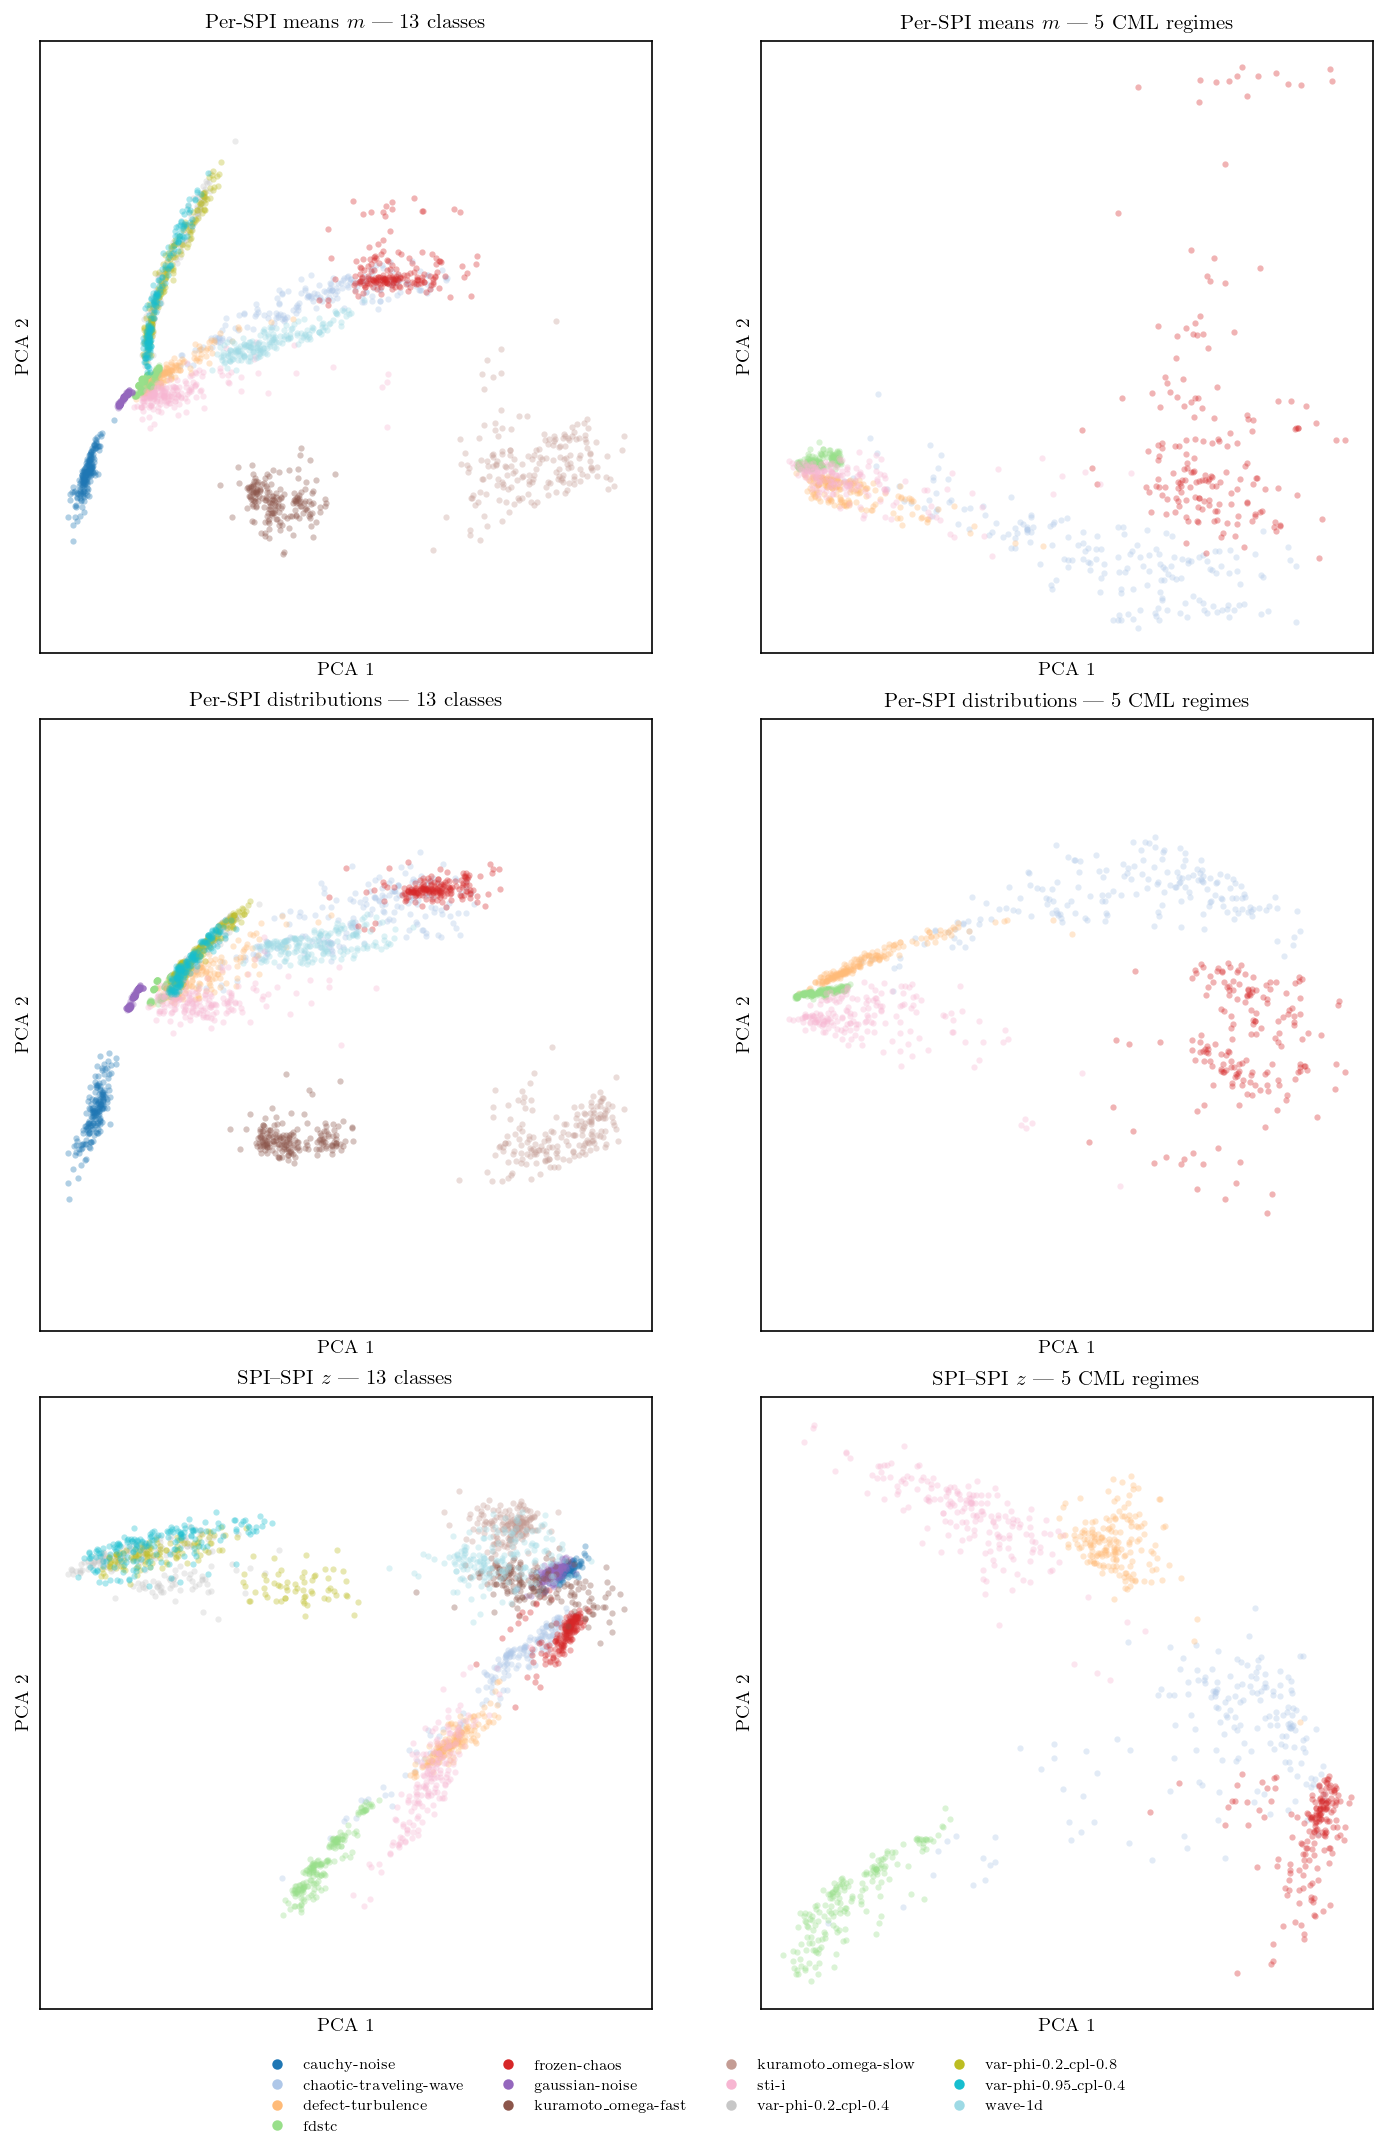

In [5]:
fig = plots.proof('pca')
plt.show()

**Quantitative checks in the fitted PCA space, not UMAP:** fixed logistic regression ($C=1$, no tuning) predicts class on evaluation realizations. Hard retrieval uses development recordings as the gallery and excludes every gallery item with either the same M or the same T as its query. Average precision is averaged across queries. CML classification/retrieval uses the five CML classes and their development rows. All methods receive identical records and splits.

These fits pool all development sizes. They do **not** reproduce the original leave-one-size-cell-out confirmation test or establish performance on previously unseen sizes. The table supports a focused retrospective comparison of representations. Raw Pearson has only two coordinates; reducing every method to two coordinates would answer a different question.

In [6]:
display(plots.proof_table())

balanced_accuracy        hard_mAP       
scope                                CML5  all14     CML5  all14
Representation                                                  
Distributions + SPI–SPI             0.989  0.977    0.927  0.823
Means + SPI–SPI                     0.983  0.975    0.920  0.811
Per-SPI distributions               0.986  0.925    0.766  0.714
Per-SPI means                       0.976  0.907    0.741  0.698
SPI–SPI                             0.991  0.983    0.940  0.818
Two Pearson summaries               0.822  0.439    0.580  0.345

In [7]:
paired = pd.read_csv(OUT / 'proof-paired.csv')
display(paired.query("metric == 'ap'").round(3))

,scope,comparison,metric,difference,low,high
1,all14,z - mean,ap,0.121,0.116,0.125
3,all14,z - distribution,ap,0.105,0.101,0.109
5,all14,mean+z - mean,ap,0.113,0.110,0.116
7,all14,distribution+z - distribution,ap,0.110,0.107,0.113
9,CML5,z - mean,ap,0.198,0.191,0.206
11,CML5,z - distribution,ap,0.174,0.166,0.181
13,CML5,mean+z - mean,ap,0.178,0.172,0.184
15,CML5,distribution+z - distribution,ap,0.161,0.155,0.167


**Reading the result:** SPI–SPI improves hard retrieval over the seven-summary baseline: all-class mAP .818 versus .714; CML mAP .940 versus .766. The all-class classification gain (.983 versus .925) is much more concentrated: about 98% of its **net** gain comes from `var-phi-0.2_cpl-0.4` and `var-phi-0.2_cpl-0.8`. Thus this is not broad evidence for detecting nonlinear mechanisms. Brownian-defect is worse under z. Within CML, classification is near ceiling and its z–distribution difference is unresolved, whereas the retrieval difference is substantial. Equal-variance fusion improves on the corresponding marginal baseline but does not uniformly improve on z.

Paired intervals resample class–instance groups, keeping their nine observation cells together, with 2,000 class-stratified bootstrap draws. They condition on the fitted development models; they do not include development-sample uncertainty or multiplicity correction. Brownian-defect and other weak classes must not be removed to improve the headline score. Exact per-record outcomes and the complete paired table are retained alongside the notebook.

## 3. Does the order-coordinate require SPI–SPI?

All six system families from the [lean benchmark notebook](../inference/order-parameter-benchmarks-lean.ipynb) are shown at their headline observation sizes. The Stuart–Landau fine sweep and the second Kaneko diagnostic are retained as additional panels. Original model fitting and evaluation divisions are preserved:

- **Kuramoto:** $\dot\theta_i=\omega_i+K N^{-1}\sum_j\sin(\theta_j-\theta_i)$; $M=N=32$, cosine observations, $T=1000$. Physical $Q$ is future mean global phase coherence $\langle|N^{-1}\sum_j e^{i\theta_j}|\rangle$. Use the original 128 development and 128 held recordings. Its original SPI–SPI PC1 misses the prechosen dominance screen; the reported association remains exploratory held-seed evidence.
- **2D coupled logistic maps:** $x_i(t+1)=(1-4g)f_r(x_i(t))+g\sum_{j\sim i}f_r(x_j(t))$, $f_r(x)=rx(1-x)$, $g=.2$, periodic $256\times256$ lattice. Physical $Q$ is the long-run absolute difference between successive even/odd spatial-mean states. Only 32 dispersed sites and 1,000 samples are observed. Baselines fit the original 36 development recordings and are applied unchanged to all 544 independent-confirmation recordings. The original frozen SPI–SPI coordinate is preserved. See the [original comparison notebook](../inference/order-parameter-benchmark-comparison.ipynb) for physical definitions, convergence checks and qualifications.

- **Stuart–Landau:** globally coupled complex oscillators; Q is mean collective amplitude. The original 240 full-observation development rows (all three M, T≥500, instances 0–3) fit each baseline once. Evaluate the 72 broad-sweep and 152 fine-sweep confirmation recordings at M=32, T=1000 with that same fitted model. The original full-arm qualification is retained; the failed partial-arm global gate is not erased.
- **Miller–Huse:** a two-dimensional chaotic coupled-map lattice with sign-domain ordering; Q is mean absolute spatial sign magnetization. Fit the original 144 development rows and evaluate the 72 M=32 confirmation recordings. The broader original confirmation required an exclusion sensitivity; this status is retained even though its excluded M=8 row is outside this headline slice.
- **Quadratic/Kaneko CML:** nearest-neighbour quadratic maps at fixed coupling .3. Fit the original 492 large-lattice development rows (instances 0–3, all three M), then evaluate the same 164 held M=32 recordings against selected spatial-band power and temporal spectral entropy. These are operational diagnostics, not a discovered canonical scalar order parameter. The same baseline coordinate is used for both targets; only its arbitrary display sign may differ.
- **Rössler:** two coupled oscillators with all six state coordinates observed; Q is mean-frequency mismatch. Fit the original 84 development recordings and evaluate all 672 independent-confirmation recordings, with the original q unchanged.

New **unsupervised** coordinates use PC1 of the means and PC1 of the seven-summary block. Filtering/scaling/centering/PCA use development observations only; neither Q nor control values select features or components. The earlier Kuramoto/2D CML fusion and standardized-z sensitivities are preserved separately. Original q values are retained; the initial two q models were reconstructed, and the extension joins the original score tables to their hashed MPI sources. Every new mean/distribution coordinate is independently replayed by NumPy SVD. Coverage is reported below.

This is a headline comparison, not every M/T/layout arm reproduced. Small 2D lattices remain diagnostic failures: L=6 failed coordinate stability; L=8 stopped on constant-channel inputs and has no valid q to compare. The original notebook retains these diagnostics and the partial-observation Kuramoto arm. They are not silently reclassified as successful inference.

Black curves show Q in physical units. Coloured learned coordinates use development SD units on the right axis. Their arbitrary signs are oriented using **development Q for display only**; this changes neither fitted representations nor absolute-rank scores. The direct mean-|r| baseline retains its raw units. Bands are 95% bootstrap intervals for the across-seed mean at each control. Dotted lines mark published boundary references, not exact finite-system thresholds.

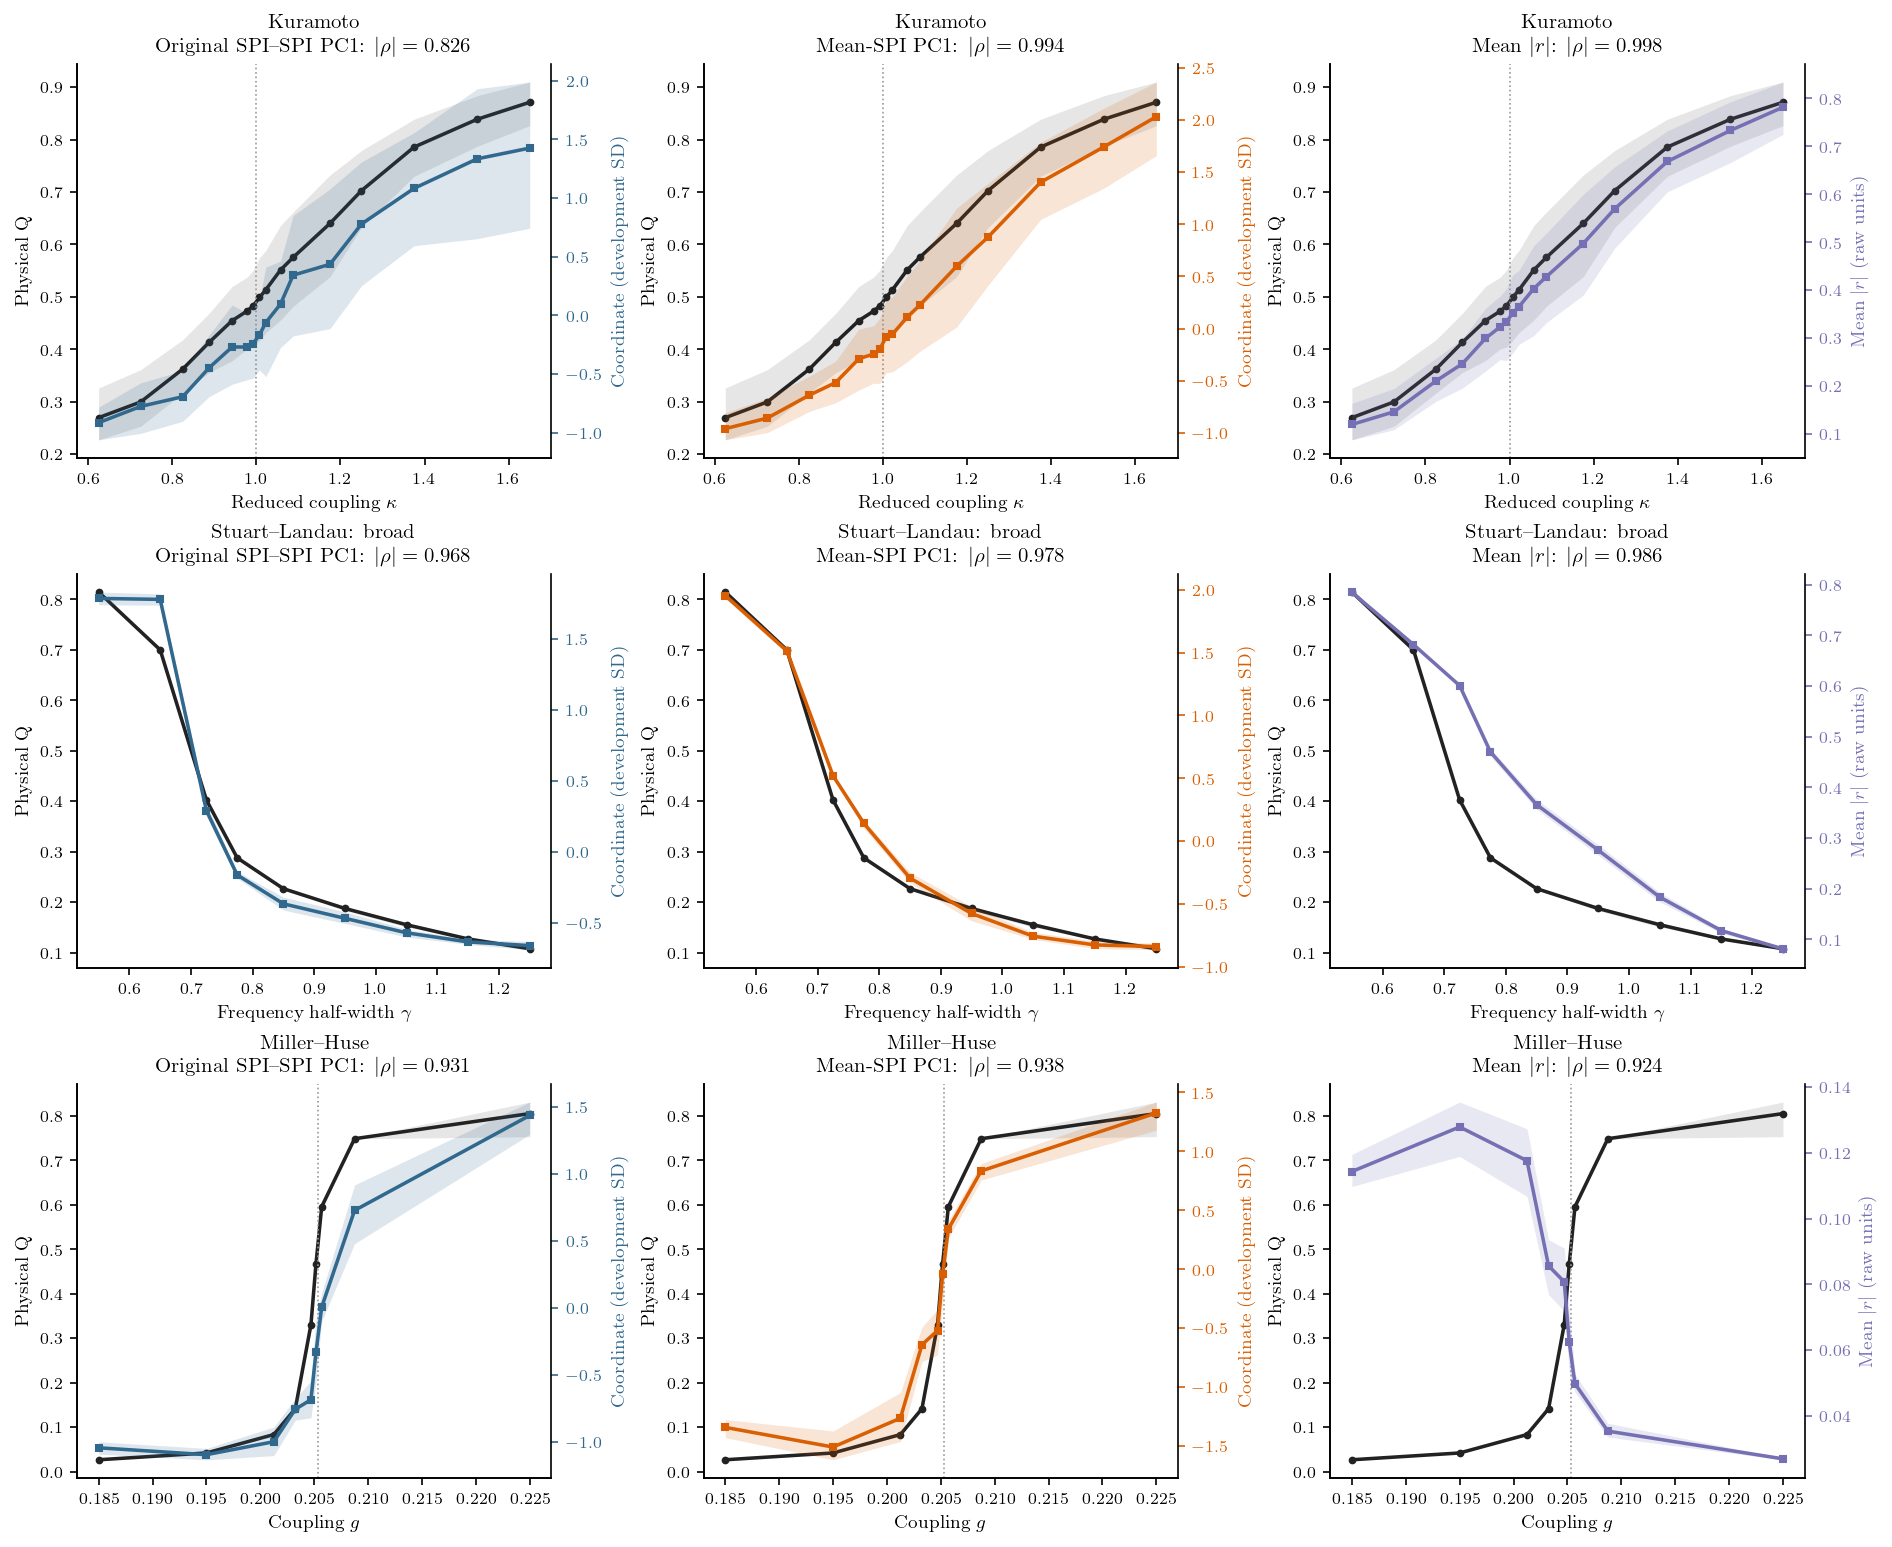

In [8]:
fig = plots.inference(('Kuramoto', 'StuartLandau', 'MillerHuse'), filename='inference-families-1')
plt.show()

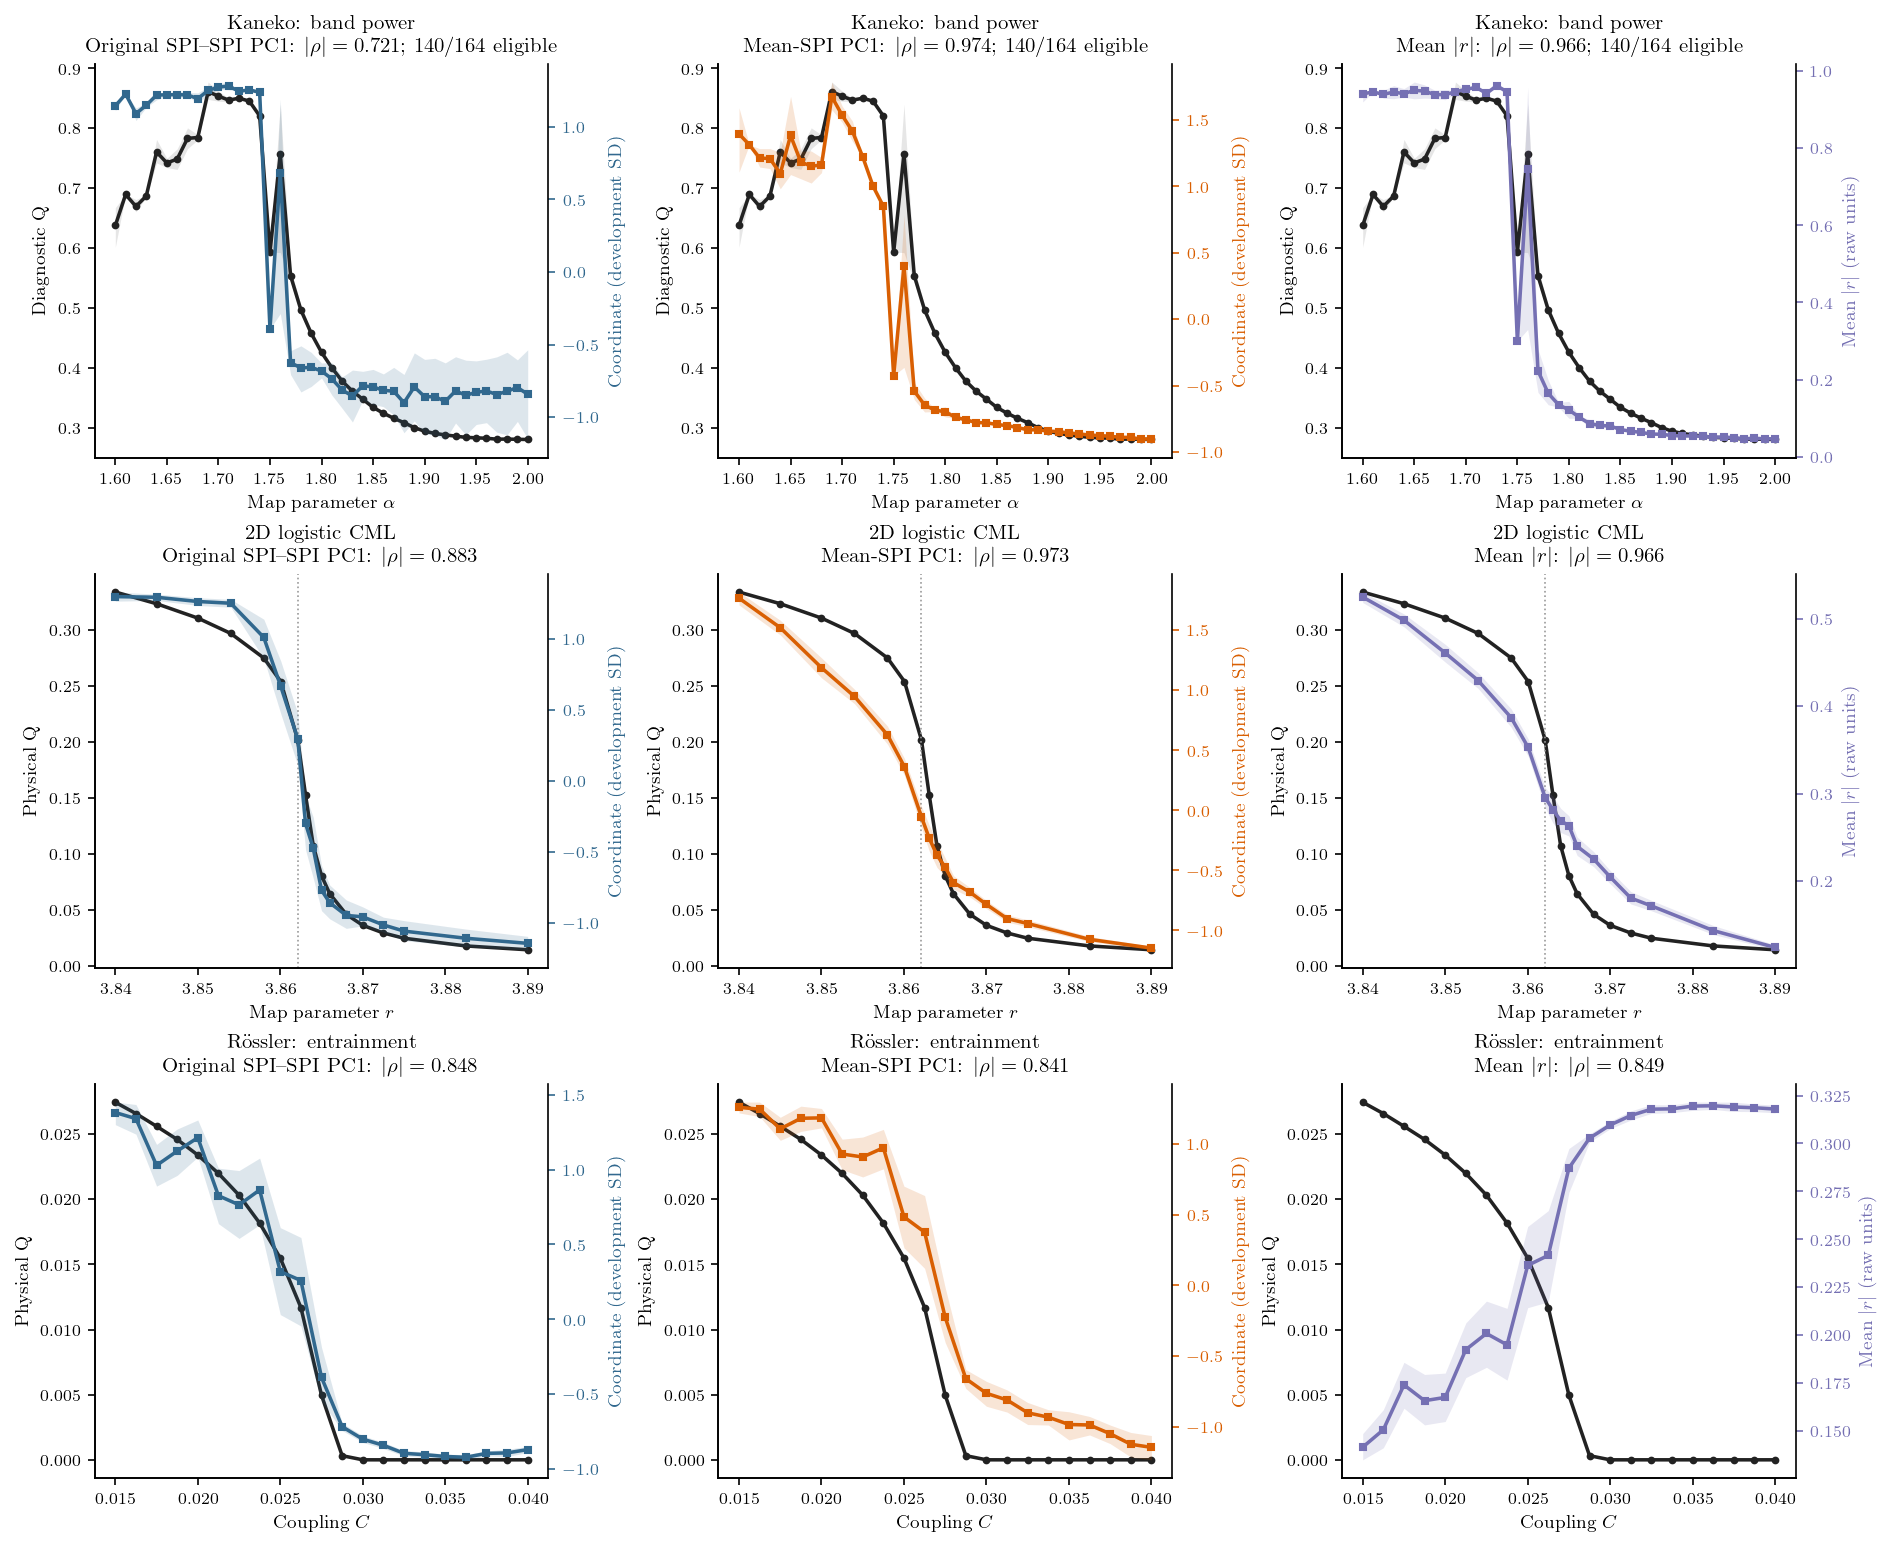

In [9]:
fig = plots.inference(('KanekoBand', 'CML2D', 'Rossler'), filename='inference-families-2')
plt.show()

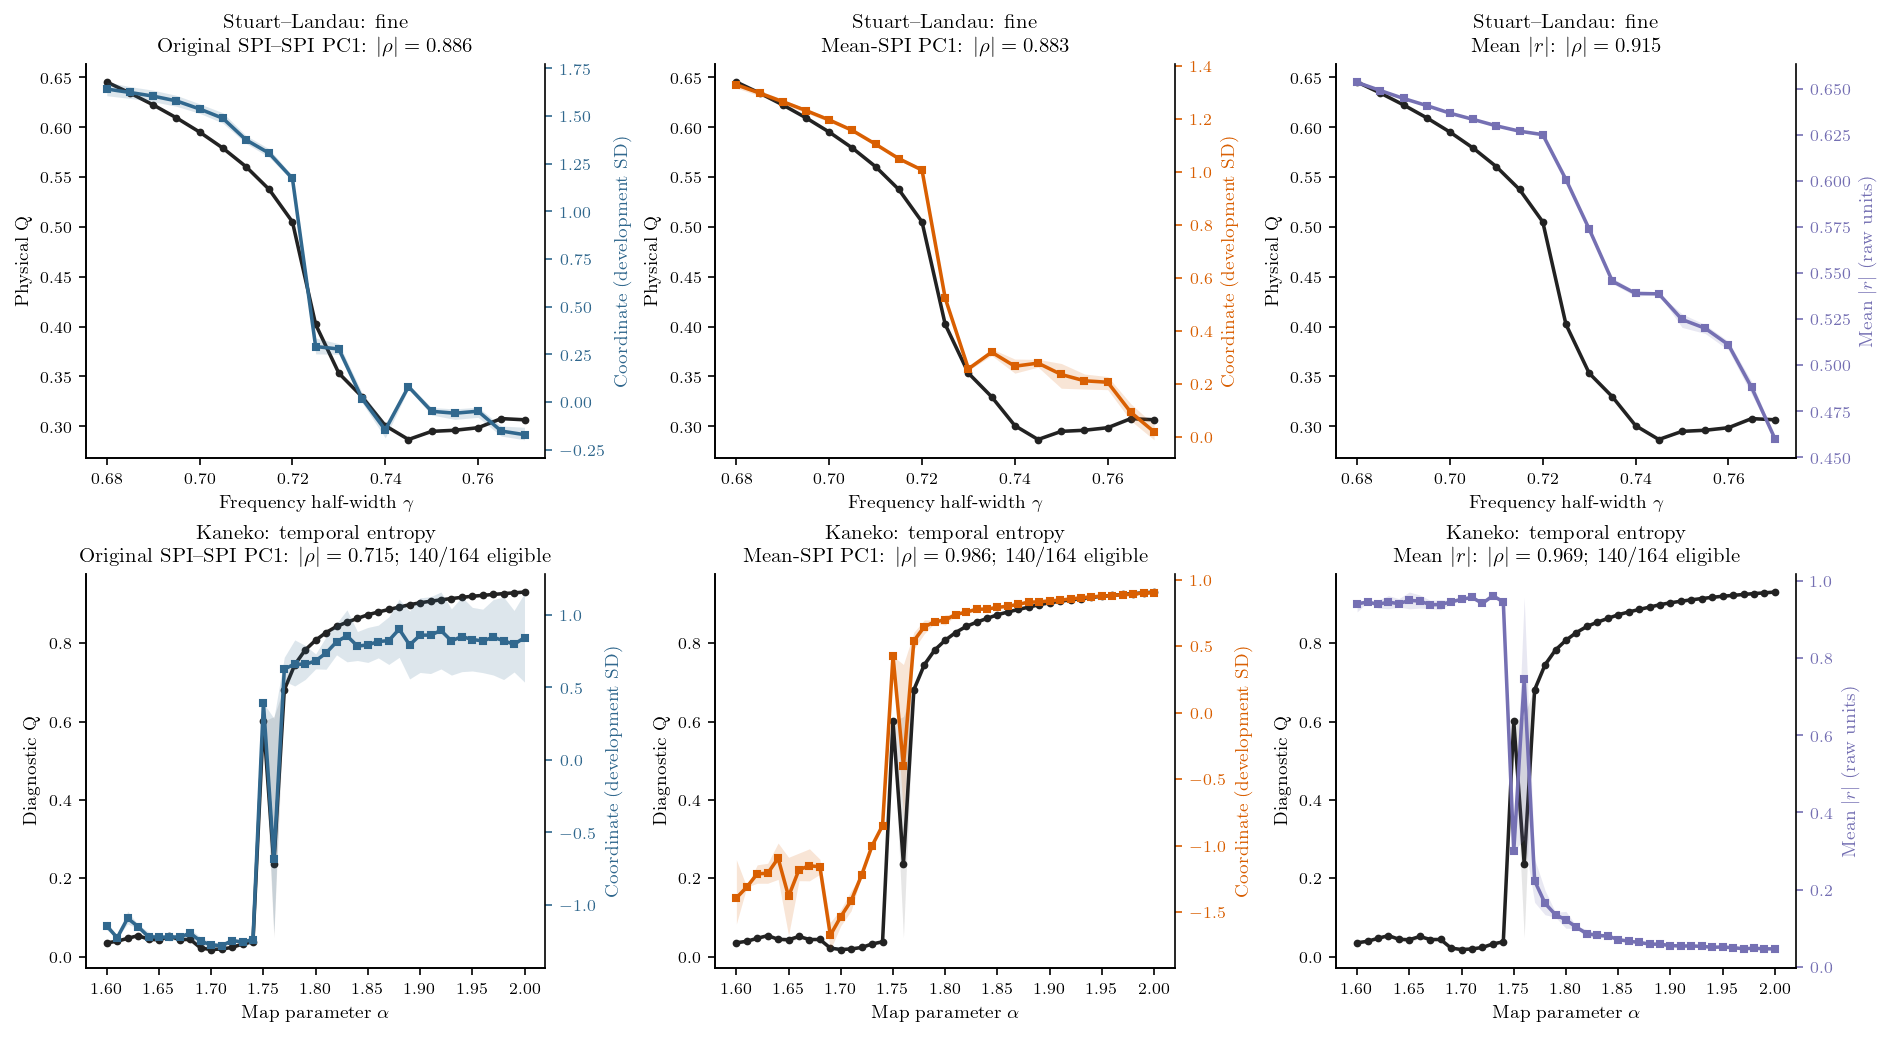

In [10]:
fig = plots.inference(('StuartLandauFine', 'KanekoEntropy'), filename='inference-additional-targets')
plt.show()

In [11]:
display(plots.inference_table(compact=True))
display(plots.inference_paired_table())

method,Original SPI–SPI PC1,Mean-SPI PC1,Distribution-SPI PC1,Mean Pearson r,Mean |r|
system,,,,,
2D logistic CML,0.883,0.973,0.973,0.889,0.966
Kaneko: band power,0.721,0.974,0.976,0.377,0.966
Kaneko: temporal entropy,0.715,0.986,0.987,0.384,0.969
Kuramoto,0.826,0.994,0.994,0.999,0.998
Miller–Huse,0.931,0.938,0.943,0.054,0.924
Rössler: entrainment,0.848,0.841,0.823,0.730,0.849
Stuart–Landau: broad,0.968,0.978,0.983,0.988,0.986
Stuart–Landau: fine,0.886,0.883,0.902,0.968,0.915


method,Distribution-SPI PC1,Mean-SPI PC1
system,,
2D logistic CML,"+0.090 [+0.075, +0.105]","+0.090 [+0.075, +0.105]"
Kaneko: band power,"+0.255 [+0.093, +0.383]","+0.253 [+0.092, +0.379]"
Kaneko: temporal entropy,"+0.272 [+0.105, +0.397]","+0.270 [+0.105, +0.394]"
Kuramoto,"+0.168 [+0.049, +0.287]","+0.168 [+0.050, +0.286]"
Miller–Huse,"+0.011 [-0.002, +0.034]","+0.007 [-0.011, +0.026]"
Rössler: entrainment,"-0.025 [-0.040, -0.010]","-0.007 [-0.018, +0.004]"
Stuart–Landau: broad,"+0.015 [+0.008, +0.025]","+0.010 [-0.001, +0.022]"
Stuart–Landau: fine,"+0.016 [+0.008, +0.022]","-0.003 [-0.014, +0.008]"


In [12]:
intervals = pd.read_csv(OUT / 'inference-transition-intervals.csv')
intervals['steepest interval'] = [f'[{a:g}, {b:g}]' for a,b in zip(intervals.interval_start, intervals.interval_end)]
display(intervals.pivot(index='method', columns='system', values='steepest interval'))

system,CML2D,Kuramoto
method,,
Q_reference,"[3.86212, 3.86306]","[1.0225, 1.0575]"
distribution_PC1,"[3.86212, 3.86306]","[0.9925, 1.0075]"
mean+z_PC1,"[3.86212, 3.86306]","[0.9925, 1.0075]"
mean_PC1,"[3.86006, 3.86212]","[0.9925, 1.0075]"
mean_abs_correlation,"[3.86006, 3.86212]","[0.9925, 1.0075]"
mean_correlation,"[3.86212, 3.86306]","[0.9925, 1.0075]"
q,"[3.86212, 3.86306]","[1.0575, 1.0875]"
temporal_spectral_entropy,"[3.86006, 3.86212]","[0.9925, 1.0075]"
z_standard_PC1,"[3.86212, 3.86306]","[0.825, 0.8875]"


Associations use individual held recordings, not just control means. The first table gives absolute Spearman association; the second gives the mean/distribution-PC1 difference from original q with 95% intervals from 2,000 paired seed-cluster bootstrap draws. Each seed's control sweep stays together. These retrospective intervals are unadjusted. Full metrics, including direct spectral/variability baselines and within-control residual associations, are retained in the two inference-metrics CSVs. Residual associations are not longitudinal fluctuation tracking.

In the initial Kuramoto and 2D CML examples, mean-SPI PC1 tracks Q strongly and combining it with SPI–SPI does not improve on that coordinate. The added systems broaden this check rather than assuming that the same outcome must recur. A weak first component does not prove the full z vector lacks useful information, and a leading variance direction is not automatically a physical order parameter.

**Added-system results:** Stuart–Landau distribution-PC1 has somewhat higher association than q in both sweeps; its mean-PC1 comparison is unresolved in the paired intervals. Miller–Huse's small mean/distribution differences are also unresolved. Rössler slightly favours q: its mean-PC1 difference is unresolved, while distribution-PC1 is lower. These are conditional, unadjusted comparisons of the specified pipelines.

**Kaneko coverage qualification:** the new marginal baselines retain 140/164 held recordings under the fixed 5% selected-feature-missingness rule. All three methods are compared on those same 140 rows; the very high marginal associations apply to this subset, not the complete sweep. Original q's full-164 associations remain .809 (band power) and .804 (entropy), compared with .721/.715 on the common subset. No q values were refitted or changed. The new marginal baselines have incomplete coverage, so this is not a whole-grid success. Only four independent held seeds support these retrospective intervals.

**Preprocessing sensitivity for the initial two systems:** PC1 of standardized z uses the same 95% validity, development SD scaling and ±5-SD clipping as the mean baseline. This check was added after observing the primary baseline results because preprocessing is a potential confound. It does not replace the frozen q or erase its original gate outcome. All methods remain retrospective and target-blind in fitting. Any advantage of one coordinate describes that representation/preprocessing combination, not every possible readout of its input.

Standardizing z improves association to .964 (Kuramoto) and .941 (CML), still below the mean coordinate (.994/.973). This sensitivity shows why the original PC1 result must not be equated with all information in z. **Rank association and transition localization are different:** on CML, q, distribution-PC1 and fusion share Q's steepest sampled interval; mean-PC1 and mean-|r| peak in the adjacent earlier interval. The interval table reports the largest absolute slope of each control-mean curve on the existing nonuniform grid, not a fitted critical point or a statistical test of localization. Kuramoto's finite-population Q interval also differs from the continuum reference and the baselines' interval. No single correlation score settles every scientific objective.

Simple coherence baselines have a physical motivation here. For phase measurements, $R^2=N^{-2}\sum_{ij}\cos(\theta_i-\theta_j)$, so average pairwise phase alignment is directly related to global synchronization. Time-series Pearson correlation of cosine observations can approximate phase alignment under suitable oscillatory/window conditions, but is not identically that observable in general. Hilbert coherence is a domain-sensitive comparator; for CML, the sampled period-two proxy uses the physical observable's form and is a model-informed comparator, not a generic baseline.

In [13]:
metrics, diagnostics = plots.inference_results()
coverage = [dict(system=s, development=d['development_rows'], held=d['common_eligible_evaluation_rows'], available=int(metrics.query('system == @s').evaluated_available.iloc[0]), held_seed_groups=int(metrics.query('system == @s').seeds.iloc[0]), mean_PC1_EVR=d['mean']['evr1'], mean_loading_stability=d['mean']['minimum_leave_seed_loading_cosine']) for s,d in diagnostics.items()]
display(pd.DataFrame(coverage).round(3))

,system,development,held,available,held_seed_groups,mean_PC1_EVR,mean_loading_stability
0,Kuramoto,128,128,128,8,0.665,0.991
1,CML2D,36,544,544,32,0.783,0.999
2,StuartLandau,240,72,72,8,0.623,1.000
3,StuartLandauFine,240,152,152,8,0.623,1.000
4,MillerHuse,144,72,72,8,0.471,0.997
5,KanekoBand,492,140,164,4,0.659,0.999
6,KanekoEntropy,492,140,164,4,0.659,0.999
7,Rossler,84,672,672,32,0.584,0.999


The loading-stability diagnostic leaves out each development seed with preprocessing held fixed, matching the style of the existing SPI–SPI diagnostic. It is not a full refit uncertainty estimate, and these new baselines are not passed through a retrospectively chosen physical-discovery gate.

## What this first pass can establish

The relevant distinction is not “simple strength” versus “all character.” Different measures already encode different scientific notions of dependence. SPI–SPI changes the representation to their system-specific relational geometry. Means offer an essential competing common space; distributions test whether a benefit survives a less severe marginal compression. The VAR example makes the distinction exact, while the proof and inference studies test whether it is useful in the existing applications.

Interpret gains by task and class, preserve the simple-baseline wins, and do not infer a unique dynamical mechanism from a position in the map. Adding a representation can also hurt under a finite PCA/readout budget. These results motivate a scoped claim about useful descriptions and their limits, not universal superiority or M,T invariance.

## Reproduction and provenance

This notebook renders the compact results produced by `scripts/spi_baseline_exploration.py`; it does not silently recompute p90. Protocol: `configs/analysis/spi-baseline-exploration-260921.yaml`. Input inventory: `data/spi_baseline_exploration_260921/proof-inputs.json`. All proof, Kuramoto and CML MPI archives are checked against their earlier recorded SHA-256 values. Source hashes and original-q replay are retained in the output provenance JSONs.

From the repository root, use the project Python to run `python -m scripts.spi_baseline_exploration toy`, `extract-proof`, `proof`, `inference`, and optionally `zenodo`. Missing cached proof files can be inventoried with `scripts/prepare_spi_baseline_data.py`; the resulting rsync list is for Gadi data-mover retrieval, not simulation. The original notebooks are unchanged. The separate corpus appendix is descriptive and transductive. Static figure files, scores, per-record outcomes and provenance live in `results/spi_baseline_exploration_260921/`.

The six-system extension is reproduced with `python -m scripts.extend_spi_baseline_inference prepare`, `extract`, and `analyze`, using the cached-file transfer list produced by `prepare`. Its protocol is `configs/analysis/spi-baseline-lean-extension-260921.yaml`; fitted states, source hashes and independent SVD replay errors are retained with the extension outputs. The reference lean notebook and figure-style document had user edits when this update began; those edits are preserved.